<a href="https://colab.research.google.com/github/SludgeDanny/Probabilidad-y-Estad-stica/blob/main/Unidad5/U5_Examen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Probabilidad y Estadistica
##Unidad 5
##Examen

###Maestro: José Gabriel Rodrigez Rivas
###Alumno: Daniel Rosales Reyes


ANÁLISIS DEL CONJUNTO DE DATOS: grupo1.csv

--- Exploración Inicial (Descripción Estadística) ---
       HorasEstudio  Calificacion
count     50.000000     50.000000
mean      14.352000     75.968000
std        4.219174     23.668867
min        3.790000     15.000000
25%       12.032500     61.000000
50%       14.600000     84.950000
75%       17.715000     94.375000
max       20.000000     99.000000


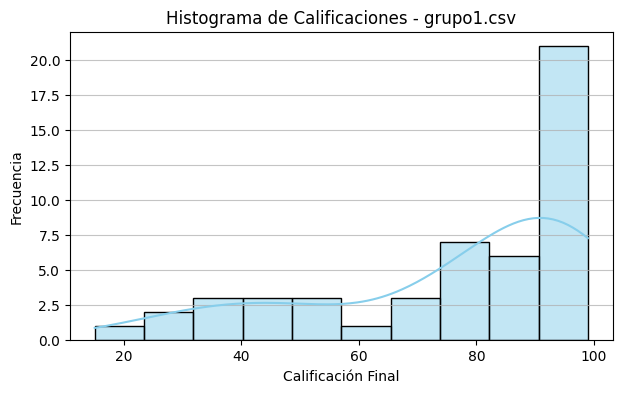


--- Ecuación de la Línea de Regresión ---
Calificación = (5.2857 * Horas de Estudio) + 0.1081

--- Correlación y Significancia ---
Coeficiente de correlación de Pearson (r): 0.9422
Valor P (Significancia estadística): 1.9342e-24


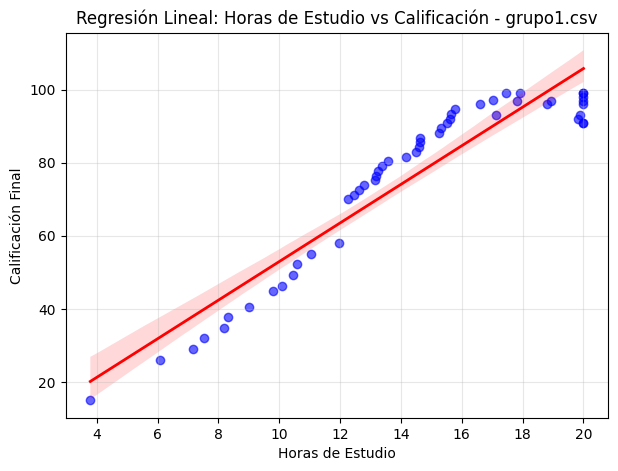


ANÁLISIS DEL CONJUNTO DE DATOS: grupo2.csv

--- Exploración Inicial (Descripción Estadística) ---
       HorasEstudio  Calificacion
count     50.000000     50.000000
mean      14.352000     75.968000
std        4.219174     23.668867
min        3.790000     15.000000
25%       12.032500     61.000000
50%       14.600000     84.950000
75%       17.715000     94.375000
max       20.000000     99.000000


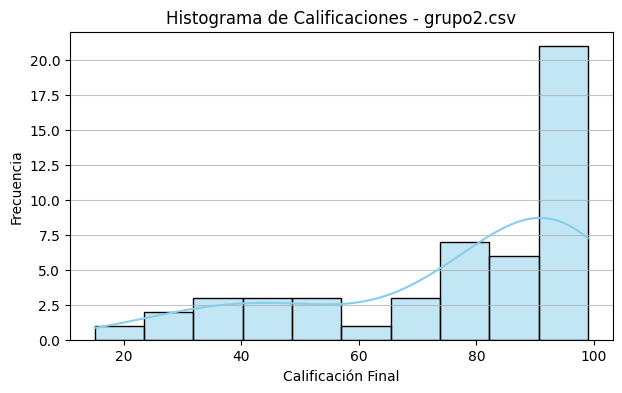


--- Ecuación de la Línea de Regresión ---
Calificación = (5.2857 * Horas de Estudio) + 0.1081

--- Correlación y Significancia ---
Coeficiente de correlación de Pearson (r): 0.9422
Valor P (Significancia estadística): 1.9342e-24


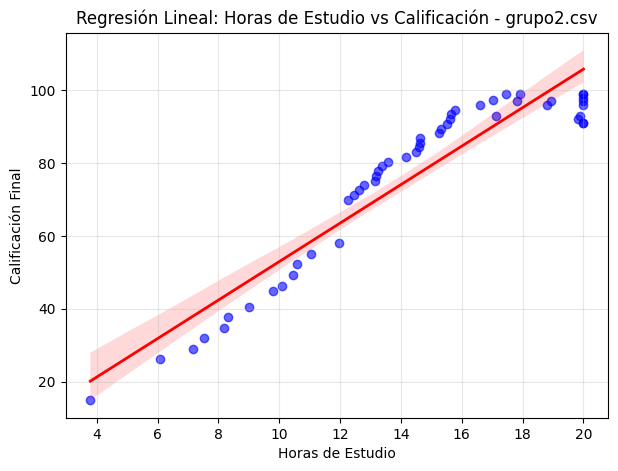


ANÁLISIS DEL CONJUNTO DE DATOS: grupo3.csv

--- Exploración Inicial (Descripción Estadística) ---
       HorasEstudio  Calificacion
count     50.000000     50.000000
mean      14.352000     75.968000
std        4.219174     23.668867
min        3.790000     15.000000
25%       12.032500     61.000000
50%       14.600000     84.950000
75%       17.715000     94.375000
max       20.000000     99.000000


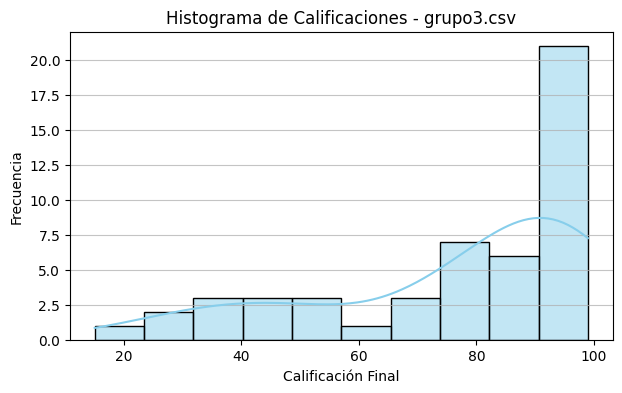


--- Ecuación de la Línea de Regresión ---
Calificación = (5.2857 * Horas de Estudio) + 0.1081

--- Correlación y Significancia ---
Coeficiente de correlación de Pearson (r): 0.9422
Valor P (Significancia estadística): 1.9342e-24


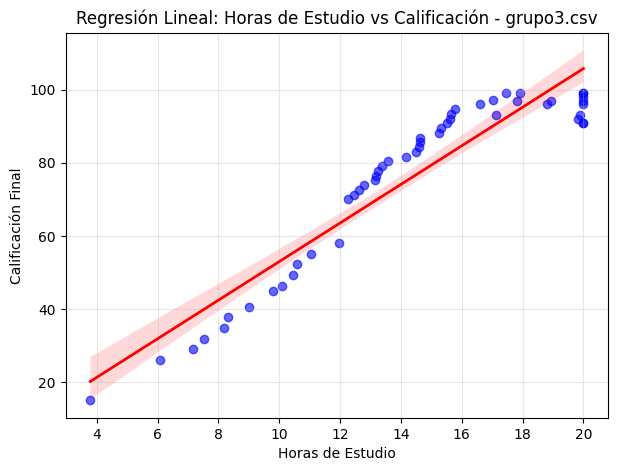

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import numpy as np

archivos = ['grupo1.csv', 'grupo2.csv', 'grupo3.csv']

for archivo in archivos:
    print(f"\n{'='*40}")
    print(f"ANÁLISIS DEL CONJUNTO DE DATOS: {archivo}")
    print(f"{'='*40}")

    try:
        df = pd.read_csv(archivo)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo {archivo}.")
        continue

    print("\n--- Exploración Inicial (Descripción Estadística) ---")
    print(df.describe())

    plt.figure(figsize=(7, 4))
    sns.histplot(df['Calificacion'], kde=True, bins=10, color='skyblue')
    plt.title(f'Histograma de Calificaciones - {archivo}')
    plt.xlabel('Calificación Final')
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    X = df[['HorasEstudio']]
    y = df['Calificacion']

    modelo = LinearRegression()
    modelo.fit(X, y)

    pendiente = modelo.coef_[0]
    intercepto = modelo.intercept_

    print("\n--- Ecuación de la Línea de Regresión ---")
    print(f"Calificación = ({pendiente:.4f} * Horas de Estudio) + {intercepto:.4f}")

    coef_corr, p_valor = pearsonr(df['HorasEstudio'], df['Calificacion'])

    print("\n--- Correlación y Significancia ---")
    print(f"Coeficiente de correlación de Pearson (r): {coef_corr:.4f}")
    print(f"Valor P (Significancia estadística): {p_valor:.4e}")

    plt.figure(figsize=(7, 5))

    sns.regplot(x='HorasEstudio', y='Calificacion', data=df, scatter_kws={'color': 'blue', 'alpha': 0.6}, line_kws={'color': 'red', 'linewidth': 2})
    plt.title(f'Regresión Lineal: Horas de Estudio vs Calificación - {archivo}')
    plt.xlabel('Horas de Estudio')
    plt.ylabel('Calificación Final')
    plt.grid(True, alpha=0.3)
    plt.show()

##¿Explicar cuál es la interpretación del coeficiente de regresión en términos de la relación entre el tiempo de estudio y las calificaciones finales?
En el grupo 3, la pendiente es positiva y alta, lo que significa que por cada hora extra de estudio, la calificación aumenta significativamente de manera constante.

En el grupo 1, la pendiente es muy cercana a cero o ligeramente negativa, lo que indica que estudiar más horas no se traduce en un aumento en la calificación.

##¿Cómo se interpreta el coeficiente de correlación en términos de la fuerza y dirección de la relación entre las variables?

Grupo 3: Tendrá un coeficiente muy cercano a 1. Esto significa que a medida que aumentan las horas de estudio, las calificaciones finales aumentan de forma casi perfectamente proporcional.  

Grupo 2: Tendrá un coeficiente positivo moderado/fuerte. Hay una tendencia clara a sacar mejores notas si se estudia más, pero los datos están más dispersos.  

Grupo 1: Tendrá un coeficiente cercano a 0. Esto indica que la fuerza de la relación lineal es nula; las variables no están correlacionadas linealmente.

##¿El modelo de regresión lineal es estadísticamente significativo?
Para los grupos 2 y 3, el valor P será extremadamente pequeño, por lo que sí es estadísticamente significativo. Existe evidencia sólida de que la relación no es producto del azar.

Para el grupo 1, el valor P será mayor, por lo que el modelo no es estadísticamente significativo. La línea de regresión trazada no es útil.

##¿Qué tan confiable es el modelo de regresión para predecir las calificaciones finales de los estudiantes basado en el tiempo de estudio?
Es altamente confiable para el grupo 3, ya que los puntos del diagrama de dispersión seguirán casi perfectamente la línea roja de predicción.

Es moderadamente confiable para el grupo 2, ya que aunque marca una tendencia correcta, habrá un margen de error considerable en las predicciones individuales debido a la dispersión.

Es nada confiable para el grupo 1. Usar las horas de estudio para predecir la calificación en este grupo producirá estimaciones completamente erróneas.